<a href="https://colab.research.google.com/github/alminha021/DS-rcf/blob/main/P02_RCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown as gd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns', None)


In [2]:
url = "https://drive.google.com/uc?id=1SHNYHvnIDfAGDcwos25WsfisfYpYl0XK"
output = "nba_stats.csv"
gd.download(url, output, quiet=False)

df = pd.read_csv(output)
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1SHNYHvnIDfAGDcwos25WsfisfYpYl0XK
To: /content/nba_stats.csv
100%|██████████| 3.50M/3.50M [00:00<00:00, 197MB/s]

   year           name  playerId     playerSlug positionId teamId    status  \
0  1999  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
1  2000  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
2  2001  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
3  2002  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
4  2003  Allen Iverson       366  allen-iverson         SG    PHI  inactive   

   gamesPlayed  avgMinutes  avgFouls  flagrantFouls  technicalFouls  \
0         48.0   41.458332  2.041667            0.0             5.0   
1         70.0   40.757140  2.314286            0.0            12.0   
2         71.0   41.957745  2.070423            0.0            18.0   
3         60.0   43.700000  1.700000            0.0            12.0   
4         82.0   42.500000  1.817073            0.0             8.0   

   ejections  doubleDouble  tripleDouble  minutes  rebounds  fouls  \
0        0.0           4.0  

In [3]:
# Número de linhas e colunas
linhas, colunas = df.shape
print(f"O dataset tem {linhas} linhas e {colunas} colunas.")

O dataset tem 8162 linhas e 54 colunas.


In [4]:
df['player_season'] = df['name'] + " (" + df['year'].astype(str) + ")"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8162 entries, 0 to 8161
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year                              8162 non-null   int64  
 1   name                              8162 non-null   object 
 2   playerId                          8162 non-null   int64  
 3   playerSlug                        8162 non-null   object 
 4   positionId                        8156 non-null   object 
 5   teamId                            8162 non-null   object 
 6   status                            8162 non-null   object 
 7   gamesPlayed                       8162 non-null   float64
 8   avgMinutes                        8162 non-null   float64
 9   avgFouls                          8162 non-null   float64
 10  flagrantFouls                     8162 non-null   float64
 11  technicalFouls                    8162 non-null   float64
 12  ejecti

In [6]:
# Mostrar apenas colunas com valores ausentes
missing = df.isnull().sum()
missing[missing > 0]

,0
positionId,6
college,1412
draftinfo,1185
birthplace,215
team,5858
htwt,5858
experience,5858


In [7]:
def converter_altura_peso(valor):
    # Separar altura e peso
    try:
        altura_str, peso_str = valor.split(", ")

        # Converter altura (ex: "6' 8"")
        pés, polegadas = altura_str.split("' ")
        pés = int(pés.strip())
        polegadas = int(polegadas.replace('"', '').strip())
        altura_cm = round((pés * 12 + polegadas) * 2.54, 1)  # 1 polegada = 2.54 cm

        # Converter peso (ex: "218 lbs")
        peso_lbs = int(peso_str.replace("lbs", "").strip())
        peso_kg = round(peso_lbs * 0.453592, 1)  # 1 libra = 0.453592 kg

        return pd.Series([altura_cm, peso_kg])
    except:
        return pd.Series([None, None])


In [8]:
#Cria as colunas "altura_cm" e "peso_kg" e transforma os valores em  altura em (cm) e peso em (kg)
df[['altura_cm', 'peso_kg']] = df['htwt'].apply(converter_altura_peso)

In [9]:
df['htwt']

,htwt
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
8157,"6' 8"", 200 lbs"
8158,"6' 8"", 205 lbs"
8159,"6' 7"", 200 lbs"
8160,"6' 3"", 180 lbs"


In [10]:
df['altura_cm']

,altura_cm
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
8157,203.2
8158,203.2
8159,200.7
8160,190.5


No Capítulo 2, seção "Handling Missing Values", ele diz:

Você NÃO deve remover colunas inteiras só porque têm muitos NaNs

Você pode usar SimpleImputer(“median”)

A mediana é estável mesmo com poucos valores

Isso evita perda de informação valiosa

In [11]:
# Remove a coluna original
df = df.drop(columns=['htwt'])

In [12]:
# Primeiro, convertemos o salário para numérico
df['salary_numeric'] = df['salary'].replace(r'[\$,]', '', regex=True).astype(float)


In [13]:
df['salary_numeric']

,salary_numeric
0,9000000.0
1,10125000.0
2,11250000.0
3,12375000.0
4,13500000.0
...,...
8157,2303520.0
8158,1719864.0
8159,3350760.0
8160,1719864.0


In [14]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

# Remover a coluna alvo
numeric_features.remove('salary_numeric')

numeric_features


['year',
 'playerId',
 'gamesPlayed',
 'avgMinutes',
 'avgFouls',
 'flagrantFouls',
 'technicalFouls',
 'ejections',
 'doubleDouble',
 'tripleDouble',
 'minutes',
 'rebounds',
 'fouls',
 'avgRebounds',
 'avgPoints',
 'avgFieldGoalsMade',
 'avgFieldGoalsAttempted',
 'fieldGoalPct',
 'avgThreePointFieldGoalsMade',
 'avgThreePointFieldGoalsAttempted',
 'threePointFieldGoalPct',
 'avgFreeThrowsMade',
 'avgFreeThrowsAttempted',
 'freeThrowPct',
 'avgAssists',
 'avgTurnovers',
 'points',
 'fieldGoalsMade',
 'fieldGoalsAttempted',
 'threePointFieldGoalsMade',
 'threePointFieldGoalsAttempted',
 'freeThrowsMade',
 'freeThrowsAttempted',
 'assists',
 'turnovers',
 'avgSteals',
 'avgBlocks',
 'steals',
 'blocks',
 'rankingSalary',
 'altura_cm',
 'peso_kg']

In [15]:
df['player_season']

,player_season
0,Allen Iverson (1999)
1,Allen Iverson (2000)
2,Allen Iverson (2001)
3,Allen Iverson (2002)
4,Allen Iverson (2003)
...,...
8157,Peyton Watson (2023)
8158,Josh Minott (2023)
8159,Dalen Terry (2023)
8160,Ryan Rollins (2023)


In [16]:
for col in ["salary_numeric", "rankingSalary", "playerId", "year"]:
    if col in numeric_features:
        numeric_features.remove(col)

numeric_features

['gamesPlayed',
 'avgMinutes',
 'avgFouls',
 'flagrantFouls',
 'technicalFouls',
 'ejections',
 'doubleDouble',
 'tripleDouble',
 'minutes',
 'rebounds',
 'fouls',
 'avgRebounds',
 'avgPoints',
 'avgFieldGoalsMade',
 'avgFieldGoalsAttempted',
 'fieldGoalPct',
 'avgThreePointFieldGoalsMade',
 'avgThreePointFieldGoalsAttempted',
 'threePointFieldGoalPct',
 'avgFreeThrowsMade',
 'avgFreeThrowsAttempted',
 'freeThrowPct',
 'avgAssists',
 'avgTurnovers',
 'points',
 'fieldGoalsMade',
 'fieldGoalsAttempted',
 'threePointFieldGoalsMade',
 'threePointFieldGoalsAttempted',
 'freeThrowsMade',
 'freeThrowsAttempted',
 'assists',
 'turnovers',
 'avgSteals',
 'avgBlocks',
 'steals',
 'blocks',
 'altura_cm',
 'peso_kg']

In [17]:
df[numeric_features].isna().sum()

,0
gamesPlayed,0
avgMinutes,0
avgFouls,0
flagrantFouls,0
technicalFouls,0
ejections,0
doubleDouble,0
tripleDouble,0
minutes,0
rebounds,0


In [18]:
df[numeric_features]

,gamesPlayed,avgMinutes,avgFouls,flagrantFouls,technicalFouls,ejections,doubleDouble,tripleDouble,minutes,rebounds,fouls,avgRebounds,avgPoints,avgFieldGoalsMade,avgFieldGoalsAttempted,fieldGoalPct,avgThreePointFieldGoalsMade,avgThreePointFieldGoalsAttempted,threePointFieldGoalPct,avgFreeThrowsMade,avgFreeThrowsAttempted,freeThrowPct,avgAssists,avgTurnovers,points,fieldGoalsMade,fieldGoalsAttempted,threePointFieldGoalsMade,threePointFieldGoalsAttempted,freeThrowsMade,freeThrowsAttempted,assists,turnovers,avgSteals,avgBlocks,steals,blocks,altura_cm,peso_kg
0,48.0,41.458332,2.041667,0.0,5.0,0.0,4.0,0.0,1990.0,236.0,98.0,4.916666,26.750000,9.062500,22.000000,41.193001,1.208333,4.145834,29.145730,7.416666,9.875000,75.105003,4.645834,3.479167,1284.0,435.0,1056.0,58.0,199.0,356.0,474.0,223.0,167.0,2.291667,0.145833,110.0,7.0,NaN,NaN
1,70.0,40.757140,2.314286,0.0,12.0,0.0,1.0,0.0,2853.0,267.0,162.0,3.814286,28.414286,10.414286,24.757143,42.066002,1.271429,3.728571,34.099618,6.314286,8.857142,71.290001,4.685714,3.285714,1989.0,729.0,1733.0,89.0,261.0,442.0,620.0,328.0,230.0,2.057143,0.071429,144.0,5.0,NaN,NaN
2,71.0,41.957745,2.070423,0.0,18.0,0.0,4.0,0.0,2979.0,273.0,147.0,3.845070,31.084507,10.732394,25.535212,42.029999,1.380282,4.309859,32.026145,8.239436,10.126760,81.362999,4.577465,3.338028,2207.0,762.0,1813.0,98.0,306.0,585.0,719.0,325.0,237.0,2.507042,0.281690,178.0,20.0,NaN,NaN
3,60.0,43.700000,1.700000,0.0,12.0,1.0,4.0,1.0,2622.0,269.0,102.0,4.483333,31.383333,11.083333,27.816668,39.844002,1.300000,4.466667,29.104477,7.916666,9.750000,81.196999,5.516667,3.950000,1883.0,665.0,1669.0,78.0,268.0,475.0,585.0,331.0,237.0,2.800000,0.216667,168.0,13.0,NaN,NaN
4,82.0,42.500000,1.817073,0.0,8.0,0.0,6.0,0.0,3485.0,344.0,149.0,4.195122,27.585365,9.804878,23.658537,41.443001,1.024390,3.695122,27.722773,6.951220,8.975610,77.445999,5.536585,3.487805,2262.0,804.0,1940.0,84.0,303.0,570.0,736.0,454.0,286.0,2.743902,0.158537,225.0,13.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8157,23.0,8.086957,0.608696,0.0,0.0,0.0,0.0,0.0,186.0,37.0,14.0,1.608696,3.260870,1.260870,2.565218,49.153000,0.260870,0.608696,42.857143,0.478261,0.869565,55.000000,0.478261,0.347826,75.0,29.0,59.0,6.0,14.0,11.0,20.0,11.0,8.0,0.086957,0.478261,2.0,11.0,203.2,90.7
8158,15.0,6.400000,0.666667,0.0,0.0,0.0,1.0,0.0,96.0,25.0,10.0,1.666667,3.066667,1.200000,2.400000,50.000000,0.133333,0.400000,33.333334,0.533333,0.533333,100.000000,0.333333,0.200000,46.0,18.0,36.0,2.0,6.0,8.0,8.0,5.0,3.0,0.266667,0.400000,4.0,6.0,203.2,93.0
8159,38.0,5.631579,0.631579,0.0,0.0,0.0,0.0,0.0,214.0,37.0,24.0,0.973684,2.236842,0.842105,1.894737,44.444000,0.184211,0.710526,25.925925,0.368421,0.552632,66.667000,0.578947,0.210526,85.0,32.0,72.0,7.0,27.0,14.0,21.0,22.0,8.0,0.289474,0.131579,11.0,5.0,200.7,90.7
8160,12.0,5.166666,0.833333,0.0,0.0,0.0,0.0,0.0,62.0,12.0,10.0,1.000000,1.916667,0.583333,1.666667,35.000000,0.250000,0.750000,33.333334,0.500000,0.500000,100.000000,0.500000,1.333333,23.0,7.0,20.0,3.0,9.0,6.0,6.0,6.0,16.0,0.083333,0.083333,1.0,1.0,190.5,81.6


In [19]:
df["salary_numeric"]

,salary_numeric
0,9000000.0
1,10125000.0
2,11250000.0
3,12375000.0
4,13500000.0
...,...
8157,2303520.0
8158,1719864.0
8159,3350760.0
8160,1719864.0


In [20]:
X = df[numeric_features]
y = df["salary_numeric"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocess = Pipeline([
    ("scaler", StandardScaler())
])


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])



In [24]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor())
])


In [25]:
model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['gamesPlayed', 'avgMinutes',
                                                   'avgFouls', 'flagrantFouls',
                                                   'technicalFouls',
                                                   'ejections', 'doubleDouble',
                                                   'tripleDouble', 'minutes',
                                                   'rebounds', 'fouls',
                                                   'avgRebounds', 'avgPoints',
                                                   'avgFieldGoalsMade',
                                                   'avgFie...
                                                   'fieldGoalPct',
                                                   'avgThreePointFieldGoalsMade',
                                                   'avgThreePointFieldGoalsAttempted',
                                                   'threePointFieldGoalPct',
                                                   'avgFreeThrowsMade',
                                                   'avgFreeThrowsAttempted',
                                                   'freeThrowPct', 'avgAssists',
                                                   'avgTurnovers', 'points',
                                                   'fieldGoalsMade',
                                                   'fieldGoalsAttempted',
                                                   'threePointFieldGoalsMade',
                                                   'threePointFieldGoalsAttempted',
                                                   'freeThrowsMade', ...])])),
                ('model', RandomForestRegressor())])

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Previsões
y_pred = model.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Desempenho do modelo:")
print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²  : {r2:.4f}")



Desempenho do modelo:
MAE : $2,970,579.65
RMSE: $4,433,896.10
R²  : 0.5966


In [27]:
df_results = X_test.copy()

# adicionar player_season de volta usando o índice original
df_results["player_season"] = df.loc[X_test.index, "player_season"]

df_results["actual_salary"] = y_test
df_results["predicted_salary"] = y_pred
df_results["difference"] = df_results["actual_salary"] - df_results["predicted_salary"]



In [28]:
df_overpaid = df_results.sort_values("difference", ascending=False)
#df_overpaid.head(20)


In [29]:
top_overpaid = df_results.sort_values("difference", ascending=False).head(20)

top_overpaid[["player_season", "actual_salary", "predicted_salary", "difference"]]


,player_season,actual_salary,predicted_salary,difference
5270,Gordon Hayward (2018),31214295.0,2219724.19,28994570.81
5483,Klay Thompson (2022),40600080.0,16423436.14,24176643.86
4504,Kevin Love (2021),31258256.0,7782920.78,23475335.22
5462,Kemba Walker (2020),34379100.0,13134425.74,21244674.26
6334,Andrew Wiggins (2022),33616770.0,13717375.10,19899394.90
7061,Pascal Siakam (2022),35448672.0,15958218.48,19490453.52
7697,Jordan Poole (2023),27955357.0,9168794.25,18786562.75
7465,Trae Young (2023),40064220.0,21303164.72,18761055.28
7470,Deandre Ayton (2023),32459438.0,14146391.45,18313046.55
7273,Bam Adebayo (2023),32600060.0,15537473.89,17062586.11


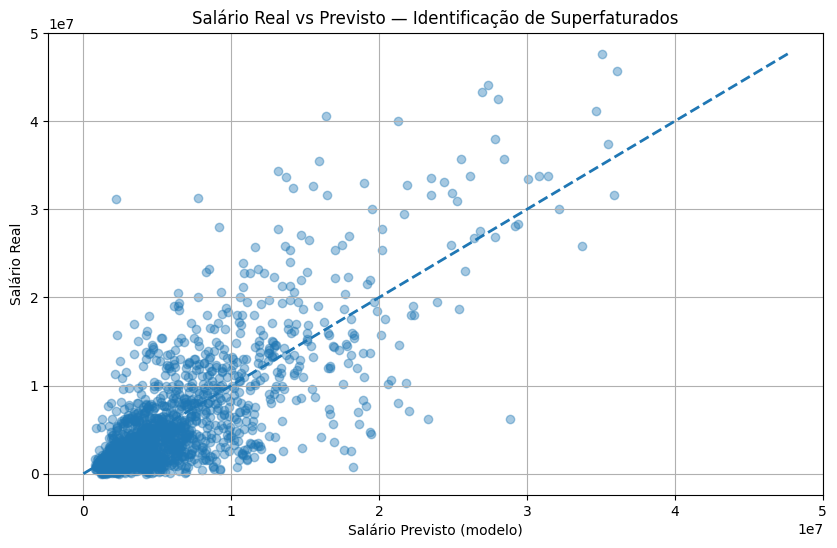

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter dos valores reais x previstos
plt.scatter(df_results["predicted_salary"], df_results["actual_salary"], alpha=0.4)

# Linha y=x (salário previsto = salário real)
max_val = max(df_results["actual_salary"].max(), df_results["predicted_salary"].max())
plt.plot([0, max_val], [0, max_val], '--', linewidth=2)

plt.xlabel("Salário Previsto (modelo)")
plt.ylabel("Salário Real")
plt.title("Salário Real vs Previsto — Identificação de Superfaturados")
plt.grid(True)
plt.show()


In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400],
    "max_features": ["auto", 20],
    "max_depth": [None, 20, 40],
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

Melhores parâmetros: {'max_depth': None, 'max_features': 20, 'n_estimators': 400}


In [34]:
# Pega o melhor modelo encontrado pelo GridSearch
best_model = grid_search.best_estimator_

# Gera previsões com o melhor modelo
y_pred_gs = best_model.predict(X_test)

# Agora pode calcular os erros
print("MAE:", mean_absolute_error(y_test, y_pred_gs))

mse = mean_squared_error(y_test, y_pred_gs)
rmse = mse ** 0.5
print("RMSE:", rmse)

print("R²:", r2_score(y_test, y_pred_gs))


MAE: 2875855.7742850585
RMSE: 4252786.915926101
R²: 0.6288835844623033


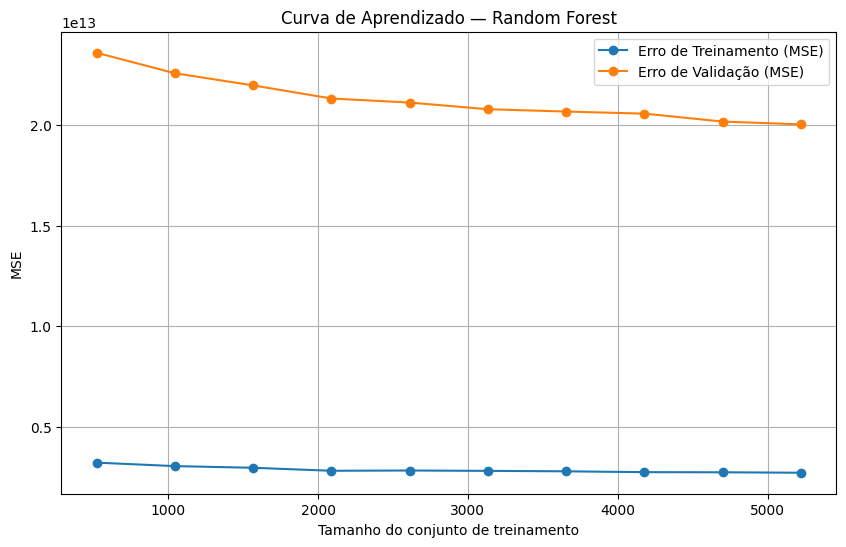

In [35]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_rf,                # modelo escolhido no GridSearch
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Convertendo de negativo para positivo (MSE)
train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mse, "o-", label="Erro de Treinamento (MSE)")
plt.plot(train_sizes, val_mse, "o-", label="Erro de Validação (MSE)")
plt.xlabel("Tamanho do conjunto de treinamento")
plt.ylabel("MSE")
plt.title("Curva de Aprendizado — Random Forest")
plt.legend()
plt.grid(True)
plt.show()


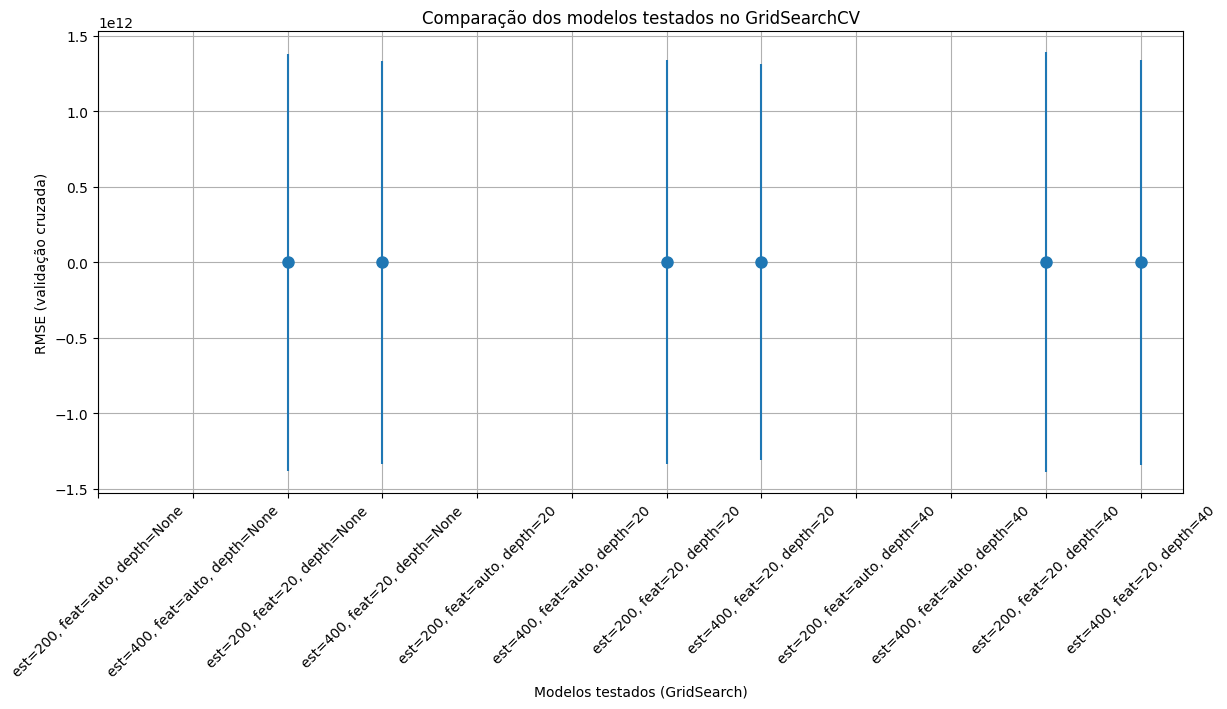

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Pegar resultados do GridSearch
cv_results = grid_search.cv_results_

# RMSE (lembrando que o scoring foi NEG_MSE)
mean_rmse = np.sqrt(-cv_results["mean_test_score"])
std_rmse = cv_results["std_test_score"]

# Criar rótulos bonitos
params = cv_results["params"]
labels = [f"est={p['n_estimators']}, feat={p['max_features']}, depth={p['max_depth']}"
          for p in params]

# Plot
plt.figure(figsize=(14,6))
plt.errorbar(range(len(mean_rmse)), mean_rmse, yerr=std_rmse, fmt='o', markersize=8)
plt.xticks(range(len(mean_rmse)), labels, rotation=45)
plt.ylabel("RMSE (validação cruzada)")
plt.xlabel("Modelos testados (GridSearch)")
plt.title("Comparação dos modelos testados no GridSearchCV")
plt.grid(True)
plt.show()


In [38]:
df_results.columns


Index(['gamesPlayed', 'avgMinutes', 'avgFouls', 'flagrantFouls',
       'technicalFouls', 'ejections', 'doubleDouble', 'tripleDouble',
       'minutes', 'rebounds', 'fouls', 'avgRebounds', 'avgPoints',
       'avgFieldGoalsMade', 'avgFieldGoalsAttempted', 'fieldGoalPct',
       'avgThreePointFieldGoalsMade', 'avgThreePointFieldGoalsAttempted',
       'threePointFieldGoalPct', 'avgFreeThrowsMade', 'avgFreeThrowsAttempted',
       'freeThrowPct', 'avgAssists', 'avgTurnovers', 'points',
       'fieldGoalsMade', 'fieldGoalsAttempted', 'threePointFieldGoalsMade',
       'threePointFieldGoalsAttempted', 'freeThrowsMade',
       'freeThrowsAttempted', 'assists', 'turnovers', 'avgSteals', 'avgBlocks',
       'steals', 'blocks', 'altura_cm', 'peso_kg', 'actual_salary',
       'predicted_salary', 'difference'],
      dtype='object')

In [39]:
df_results = X_test.copy()

# adicionar player_season de volta usando o índice original
df_results["player_season"] = df.loc[X_test.index, "player_season"]

df_results["actual_salary"] = y_test
df_results["predicted_salary"] = y_pred_gs   # <- usar o modelo do GridSearch
df_results["difference"] = df_results["actual_salary"] - df_results["predicted_salary"]


In [40]:
top_overpaid = df_results.sort_values("difference", ascending=False).head(20)
top_overpaid[["player_season", "actual_salary", "predicted_salary", "difference"]]


,player_season,actual_salary,predicted_salary,difference
5270,Gordon Hayward (2018),31214295.0,1.803884e+06,2.941041e+07
4504,Kevin Love (2021),31258256.0,8.996290e+06,2.226197e+07
7465,Trae Young (2023),40064220.0,1.833681e+07,2.172741e+07
5483,Klay Thompson (2022),40600080.0,1.892777e+07,2.167231e+07
5462,Kemba Walker (2020),34379100.0,1.352471e+07,2.085439e+07
6334,Andrew Wiggins (2022),33616770.0,1.287782e+07,2.073895e+07
7697,Jordan Poole (2023),27955357.0,1.145964e+07,1.649572e+07
7470,Deandre Ayton (2023),32459438.0,1.615587e+07,1.630357e+07
7273,Bam Adebayo (2023),32600060.0,1.679645e+07,1.580361e+07
2579,LeBron James (2018),35654150.0,2.023002e+07,1.542413e+07
